
> **Reference:** VanderPlas, Jake. **Python data science handbook**: Essential tools for working with data. " O'Reilly Media, Inc.", 2016.


# CHAPTER 3 - PART 2

In [1]:
import numpy as np
import pandas as pd
pd.__version__

'2.2.2'

# 1- Concatenating Datasets: `pd.concat()`

Some of the most interesting studies of data come from combining different data  sources. These operations can involve anything from very straightforward **concatenation of two different datasets**, to more complicated database-style joins and merges  that correctly handle any overlaps between the datasets. **Series** and **DataFrames** are  built with this type of operation in mind, and Pandas includes functions and methods  that make this sort of data wrangling fast and straightforward.

Here we’ll take a look at simple concatenation of **Series** and **DataFrames** with the  `pd.concat` function; later we’ll dive into more sophisticated in-memory merges and  joins implemented in Pandas.

For convenience, we’ll define this function, which creates a **DataFrame** of a particular  form that will be useful below:

In [2]:
def make_df(cols, ind):
    """Quickly make a DataFrame"""
    data = {c: [str(c) + str(i) for i in ind] for c in cols}
    return pd.DataFrame(data, ind)
# example DataFrame
make_df('ABC', range(3))

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2


## Recall: Concatenation of NumPy Arrays

Recall that with it, you can combine the  contents of two or more arrays into a single array:

In [3]:
x = [1, 2, 3]
y = [4, 5, 6]
z = [7, 8, 9]
np.concatenate([x, y, z])

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

The first argument is a list or tuple of arrays to concatenate. Additionally, it takes an  `axis` keyword that allows you to specify **the axis along which the result will be  concatenated**:

In [4]:
x = [[1, 2],
     [3, 4]]
np.concatenate([x, x], axis=1)

array([[1, 2, 1, 2],
       [3, 4, 3, 4]])

## Simple Concatenation with `pd.concat()`

Pandas has a function, pd.concat(), which has a similar syntax to np.concatenate  but contains a number of options that we’ll discuss momentarily:

`pd.concat()` can be used for a simple concatenation of **Series** or **DataFrame** objects,  just as np.concatenate() can be used for simple concatenations of arrays:

In [5]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
print(ser1)
print(ser2)
pd.concat([ser1, ser2])  # concat on top of each other

1    A
2    B
3    C
dtype: object
4    D
5    E
6    F
dtype: object


,0
1,A
2,B
3,C
4,D
5,E
6,F


It also works to concatenate higher-dimensional objects, such as **DataFrames**:

In [6]:
df1 = make_df('AB', [1, 2])
df2 = make_df('AB', [3, 4])
print(df1)
print(df2)
pd.concat([df1, df2])  # On top of each other

    A   B
1  A1  B1
2  A2  B2
    A   B
3  A3  B3
4  A4  B4


,A,B
1,A1,B1
2,A2,B2
3,A3,B3
4,A4,B4


Note using the `axis` keyword:

In [7]:
df3 = make_df('AB', [0, 1])
df4 = make_df('CD', [0, 1])
print(df3)
print(df4)
pd.concat([df3, df4], axis='columns')  # Beside each other

    A   B
0  A0  B0
1  A1  B1
    C   D
0  C0  D0
1  C1  D1


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1


In [8]:
# Equivalent to,
pd.concat([df3, df4], axis=1)  # Beside each other

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1


### Duplicate indices

One important difference between `np.concatenate` and `pd.concat` is that **Pandas  concatenation preserves indices**, **even if the result will have duplicate indices!** Consider  this simple example:

In [9]:
x = make_df('AB', [0, 1])
y = make_df('AB', [2, 3])
y.index = x.index  # make duplicate indices!
print(x)
print(y)
pd.concat([x, y])

    A   B
0  A0  B0
1  A1  B1
    A   B
0  A2  B2
1  A3  B3


,A,B
0,A0,B0
1,A1,B1
0,A2,B2
1,A3,B3


Notice the repeated indices in the result. While this is valid within DataFrames, the  outcome is often undesirable. `pd.concat`() gives us a few ways to handle it.

#### Catching the repeats as an error

If you’d like to simply verify that the indices in the  result of `pd.concat`() do not overlap, you can specify the verify_integrity flag.  With this set to True, the concatenation will raise an exception if there are duplicate  indices. Here is an example, where for clarity we’ll catch and print the error message:

In [10]:
try:
    pd.concat([x, y], verify_integrity=True)
except ValueError as e:
    print('ValueError: ', e)

ValueError:  Indexes have overlapping values: Index([0, 1], dtype='int64')


#### Ignoring the index

Sometimes the index itself does not matter, and you would prefer  it to **simply be ignored**. You can specify this option using the `ignore_index` flag. With  this set to True, **the concatenation will create a new integer index for the resulting Series**:

In [11]:
print(x)
print(y)
pd.concat([x, y], ignore_index=True)  # New sequential index

    A   B
0  A0  B0
1  A1  B1
    A   B
0  A2  B2
1  A3  B3


,A,B
0,A0,B0
1,A1,B1
2,A2,B2
3,A3,B3


### Concatenation with joins

In the simple examples we just looked at, we were mainly concatenating DataFrames  with shared column names. In practice, data from different sources might have different sets of column names, and `pd.concat` offers several options in this case. Consider  the concatenation of the following two DataFrames, which have some (but not all!)  columns in common:

In [12]:
df5 = make_df('ABC', [1, 2])
df6 = make_df('BCD', [3, 4])
print(df5)
print(df6)
pd.concat([df5, df6])

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4


,A,B,C,D
1,A1,B1,C1,NaN
2,A2,B2,C2,NaN
3,NaN,B3,C3,D3
4,NaN,B4,C4,D4


By default, the entries for which no data is available are filled **with NA values**. To  change this, we can specify one of several options for the `join` and `join_axes` parameters of the concatenate function. By default, the join is a **union** of the input columns  (`join='outer'`), but we can change this to an **intersection** of the columns using  `join='inner'`:

In [13]:
print(df5)
print(df6)
pd.concat([df5, df6], join='outer')  # Default: column union

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4


,A,B,C,D
1,A1,B1,C1,NaN
2,A2,B2,C2,NaN
3,NaN,B3,C3,D3
4,NaN,B4,C4,D4


In [14]:
print(df5)
print(df6)
pd.concat([df5, df6], join='inner')  # column intersection

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4


,B,C
1,B1,C1
2,B2,C2
3,B3,C3
4,B4,C4


Another option is to specify the  returned columns using the `columns` attribute of `reindex()`:

In [15]:
print(df5)
print(df6)
print(pd.concat([df5, df6]))
pd.concat([df5, df6]).reindex(columns=df5.columns)
# NOTE: join_axes parameter is obsolete, so use the reindex() instead
# NOTE: the DataFrame append() is deprecated

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4
     A   B   C    D
1   A1  B1  C1  NaN
2   A2  B2  C2  NaN
3  NaN  B3  C3   D3
4  NaN  B4  C4   D4


,A,B,C
1,A1,B1,C1
2,A2,B2,C2
3,NaN,B3,C3
4,NaN,B4,C4


# 2- Joining Datasets: `pd.merge()`

One essential feature offered by Pandas is its high-performance, in-memory join and merge operations. If you have ever worked with databases, you should be familiar with this type of data interaction. The main interface for this is the pd.merge function, and we'll see a few examples of how this can work in practice.

## Relational Algebra

The behavior implemented in `pd.merge()` is a subset of what is known as **relational algebra**, which is a formal set of rules for manipulating relational data, and forms the conceptual foundation of operations available in most databases. The strength of the **relational algebra** approach is that it proposes several **primitive operations**, which become the building blocks of more complicated operations on any dataset. With this lexicon of fundamental operations implemented efficiently in a database or other program, a wide range of fairly complicated composite operations can be performed.

Pandas implements several of these fundamental building blocks in the `pd.merge()` function and the related `join()` method of `Series` and `DataFrames`. As we will see, these let you efficiently link data from different sources.

## Categories of Joins

The `pd.merge()` function implements a number of types of joins: the **one-to-one**, **many-to-one**, and **many-to-many** joins. All three types of joins are accessed via an identical call to the `pd.merge()` interface; the type of join performed depends on the form of the input data.

In [16]:
import pandas as pd
import numpy as np

### One-to-one joins

Perhaps the simplest type of merge expression is the **one-to-one join**, which is in  many ways very similar to the column-wise concatenation. As a concrete example, consider the following  two `DataFrames`, which contain information on several employees in a company:

In [17]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})
print(df1); print(df2)

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
  employee  hire_date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014


To combine this information into a single `DataFrame`, we can use the `pd.merge()`  function:

In [18]:
df3 = pd.merge(df1, df2)  # Common key columns: employee, not having duplicates
df3

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


You are performing a **one-to-one join**, which is the simplest type of merge in Pandas. It behaves very similarly to an **INNER JOIN** in SQL.

Explanation:

Here is the explanation of how `df3 = pd.merge(df1, df2)` produced that specific output:

1: The Common Key: employee

Pandas automatically looked for columns with the same name in both df1 and df2. It found the employee column and used it as the **key** to align the rows.

* df1 contains: employee and group.
* df2 contains: employee and hire_date.

2: Row Alignment and Reordering

Notice that the order of employees in df2 is different from df1:

* In df1, the order is Bob, Jake, Lisa, Sue.
* In df2, the order is Lisa, Bob, Jake, Sue.

The pd.merge() function finds the matching name in both tables and "stitches" the corresponding data together into a single row. For example, it sees "Lisa" in df1 (Engineering) and finds "Lisa" in df2 (2004), creating a single combined row for her.



3: The Resulting DataFrame (df3)

The final output is a single DataFrame that contains the intersection of both sets of columns:

* Columns: employee, group, and hire_date.
* Index: A new RangeIndex (0, 1, 2, 3) is created for the merged result.

Additionally, keep in mind that the merge in general discards  the index, except in the special case of merges by index (see “The left_index and  `right_index` keywords”).

### Many-to-one joins

Many-to-one joins are joins in which one of the two key columns contains duplicate  entries. For the **many-to-one** case, the resulting `DataFrame` will preserve those duplicate entries as appropriate. Consider the following example of a **many-to-one join**:

In [19]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                    'supervisor': ['Carly', 'Guido', 'Steve']})
print(df3); print(df4);
pd.merge(df3, df4)  # Common key columns: group, one is having duplicates

  employee        group  hire_date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014
         group supervisor
0   Accounting      Carly
1  Engineering      Guido
2           HR      Steve


,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


The resulting `DataFrame` has an additional column with the “supervisor” information,  where the information is repeated in one or more locations as required by the inputs.

### Many-to-many joins

Many-to-many joins are a bit confusing conceptually, but are nevertheless well  defined. If the key column in both the left and right array contains duplicates, then  the result is a **many-to-many** merge. This will be perhaps most clear with a concrete  example. Consider the following, where we have a `DataFrame` showing one or more  skills associated with a particular group.

By performing a **many-to-many join**, we can recover the skills associated with any  individual person:

In [20]:
df5 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                              'Engineering', 'Engineering', 'HR', 'HR'],
                    'skills': ['math', 'spreadsheets', 'coding', 'linux',
                              'spreadsheets', 'organization']})
print(df1); print(df5);
pd.merge(df1, df5)  # Common key columns: group, both having duplicates

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
         group        skills
0   Accounting          math
1   Accounting  spreadsheets
2  Engineering        coding
3  Engineering         linux
4           HR  spreadsheets
5           HR  organization


,employee,group,skills
0,Bob,Accounting,math
1,Bob,Accounting,spreadsheets
2,Jake,Engineering,coding
3,Jake,Engineering,linux
4,Lisa,Engineering,coding
5,Lisa,Engineering,linux
6,Sue,HR,spreadsheets
7,Sue,HR,organization


These three types of joins can be used with other Pandas tools to implement a wide  array of functionality. But in practice, datasets are rarely as clean as the one we’re  working with here. In the following section, we’ll consider some of the options provided by `pd.merge()` that enable you to tune how the join operations work.

## Specification of the Merge Key

We’ve already seen the default behavior of `pd.merge()`: it looks for one or more  matching column names between the two inputs, and uses this as the key. However,  often the column names will not match so nicely, and `pd.merge()` provides a variety  of options for handling this.

#### The `on` keyword

Most simply, you can explicitly specify the name of the key column using the `on` keyword, which takes a column name or a list of column names:

In [21]:
print(df1); print(df2);
pd.merge(df1, df2, on='employee')  # Specifies the key column (the on parameter)

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
  employee  hire_date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


This option works only if both the left and right `DataFrames` have the specified column name.

#### The `left_on` and `right_on` keywords

At times you may wish to merge two datasets with different column names; for example, we may have a dataset in which the employee name is labeled as “name” rather  than “employee”. In this case, we can use the `left_on` and `right_on` keywords to  specify the two column names:

In [22]:
df3 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'salary': [70000, 80000, 120000, 90000]})
print(df1); print(df3);
pd.merge(df1, df3, left_on="employee", right_on="name")
# Joins on 'employee' from left = ''name' from right
# NOTE: both columns are kept in the result

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
   name  salary
0   Bob   70000
1  Jake   80000
2  Lisa  120000
3   Sue   90000


,employee,group,name,salary
0,Bob,Accounting,Bob,70000
1,Jake,Engineering,Jake,80000
2,Lisa,Engineering,Lisa,120000
3,Sue,HR,Sue,90000


The result has a redundant column that we can drop if desired—for example, by  using the `drop()` method of `DataFrames`:

In [23]:
# Merge with different column names
pd.merge(df1, df3, left_on="employee", right_on="name").drop('name', axis=1)

,employee,group,salary
0,Bob,Accounting,70000
1,Jake,Engineering,80000
2,Lisa,Engineering,120000
3,Sue,HR,90000


#### The `left_index` and `right_index` keywords

Sometimes, rather than merging on a **column**, you would instead like to merge on an  **index**. For example, your data might look like this:

In [24]:
print(df1); print(df2)

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
  employee  hire_date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014


In [25]:
df1a = df1.set_index('employee')
df2a = df2.set_index('employee')
print(df1a); print(df2a)

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire_date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014


You can use the index as the key for merging by specifying the `left_index` and/or  `right_index` flags in `pd.merge()`:

In [26]:
print(df1a); print(df2a);
pd.merge(df1a, df2a, left_index=True, right_index=True)

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire_date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014


,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


For convenience, `DataFrames` implement the `join()` method, which performs a  merge that defaults to joining on **indices**:

In [27]:
print(df1a); print(df2a);
df1a.join(df2a)

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire_date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014


,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


If you’d like to mix indices and columns, you can combine `left_index` with `right_on`  **or** `left_on` with `right_index` to get the desired behavior:

In [28]:
print(df1a); print(df3);
pd.merge(df1a, df3, left_index=True, right_on='name')

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
   name  salary
0   Bob   70000
1  Jake   80000
2  Lisa  120000
3   Sue   90000


,group,name,salary
0,Accounting,Bob,70000
1,Engineering,Jake,80000
2,Engineering,Lisa,120000
3,HR,Sue,90000


How the Resultant Index is Generated:

In the merge operation, the generation of the resultant index follows specific Pandas rules for joining a DataFrame with a **named index** and a DataFrame with a **RangeIndex**.

1: Pre-Merge State

* Left DataFrame (df1a): Has a labeled index (employee: Bob, Jake, Lisa, Sue).
* Right DataFrame (df3): Has a standard RangeIndex (0, 1, 2, 3) and a column named name.

2: How the Resultant Index is Determined

When you use `left_index=True` and `right_on='name'`, Pandas prioritizes the index of the side where you used a **column key**.

* **The Winner**: Since you joined on a column from the "right" DataFrame (df3), the resultant DataFrame inherits the RangeIndex (0, 1, 2, 3) from df3.
* **The Dropped Index**: The index of df1a (the employee names) is essentially "consumed" by the join. It doesn't disappear entirely; rather, its values are aligned with the name column. Because the information is now represented in the name column, Pandas does not keep the old text-based index as the primary index to avoid redundancy.

3: Key Rule for Merging

> If you merge two DataFrames and only one of them uses `left_index=True` (or `right_index=True`), the index of the **other** DataFrame (the one using a column) is preserved in the output.

## Specifying Set Arithmetic for Joins

In all the preceding examples we have glossed over one important consideration in  performing a join: the type of set arithmetic used in the join. This comes up when a  value appears in one key column but not the other. Consider this example:

In [29]:
df6 = pd.DataFrame({'name': ['Peter', 'Paul', 'Mary'],
                    'food': ['fish', 'beans', 'bread']},
                   columns=['name', 'food'])
df7 = pd.DataFrame({'name': ['Mary', 'Joseph'],
                    'drink': ['wine', 'beer']},
                   columns=['name', 'drink'])
print(df6); print(df7);
pd.merge(df6, df7)

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer


,name,food,drink
0,Mary,bread,wine


Here we have merged two datasets that have only a single “name” entry in common:  Mary. By default, the result contains the **intersection** of the two sets of inputs; this is  what is known as an **inner join**. We can specify this explicitly using the `how` keyword,  which defaults to `'inner'`:

In [30]:
# Inner join (default) - intersection of keys
pd.merge(df6, df7, how='inner')

,name,food,drink
0,Mary,bread,wine


Other options for the `how` keyword are `'outer'`, `'left'`, and `'right'`. An **outer** join  returns a join over the **union** of the input columns, and fills in all missing values with  **NAs**:

In [31]:
print(df6); print(df7);
pd.merge(df6, df7, how='outer')

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer


,name,food,drink
0,Joseph,NaN,beer
1,Mary,bread,wine
2,Paul,beans,NaN
3,Peter,fish,NaN


The **left join** **and right** join return join over the left entries and right entries, respectively. For example:

In [32]:
print(df6); print(df7);
pd.merge(df6, df7, how='left')

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer


,name,food,drink
0,Peter,fish,NaN
1,Paul,beans,NaN
2,Mary,bread,wine


The output rows now correspond to the entries in the left input. Using how='right'  works in a similar manner.

All of these options can be applied straightforwardly to any of the preceding join  types.

## Overlapping Column Names: The `suffixes` Keyword

Finally, you may end up in a case where your two input `DataFrames` have conflicting  column names. Consider this example:

In [33]:
df8 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'rank': [1, 2, 3, 4]})
df9 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'rank': [3, 1, 4, 2]})
print(df8); print(df9);
pd.merge(df8, df9, on="name")
# NOTE: rank is a common column name, but not chosen in 'on'

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     3
1  Jake     1
2  Lisa     4
3   Sue     2


,name,rank_x,rank_y
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


Because the output would have two conflicting column names, the merge function  automatically appends a suffix _x or _y to make the output columns unique. If these  defaults are inappropriate, it is possible to specify a custom suffix using the `suffixes`  keyword:

In [34]:
print(df8); print(df9);
pd.merge(df8, df9, on="name", suffixes=["_L", "_R"])

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     3
1  Jake     1
2  Lisa     4
3   Sue     2


,name,rank_L,rank_R
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


These suffixes work in any of the possible join patterns, and work also if there are  multiple overlapping columns.

Note what happens if we drop the `on` keyword while having two columns common:

In [35]:
print(df8); print(df9);
pd.merge(df8, df9)
# NOTE: the result is empty because the combination <name, rank>
# has 0 matching from the other dataframe.
# (example, Bob 1 in left and Bob 3 in right)

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     3
1  Jake     1
2  Lisa     4
3   Sue     2


,name,rank


In [36]:
df10 = pd.DataFrame({'name': ['Bob', 'Jake', 'Sue', 'Lisa'], 'rank': [1, 3, 4, 2]})
print(df8); print(df10);
pd.merge(df8, df10)  # Here we hve common <name, rank> combination

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     1
1  Jake     3
2   Sue     4
3  Lisa     2


,name,rank
0,Bob,1
1,Sue,4


# 3- Aggregation and Grouping

An essential piece of analysis of large data is efficient summarization: computing aggregations like **sum(), mean(), median(), min(), and max()**, in which a single number gives insight into the nature of a potentially large dataset. In this section, we'll explore aggregations in Pandas, from simple operations akin to what we've seen on NumPy arrays, to more sophisticated operations based on the concept of a **groupby**.

**Planets Data**

Here we will use the **Planets** dataset, available via the Seaborn package. It gives information on planets that astronomers  have discovered around other stars (known as extrasolar planets or exoplanets for  short). It can be downloaded with a simple Seaborn command:

In [37]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [38]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


## Simple Aggregation in Pandas

As with a onedimensional NumPy array, for a Pandas `Series`, the aggregates return **a single value**:

In [39]:
# On a Series object
rng = np.random.RandomState(42)
ser = pd.Series(rng.rand(5))
ser

,0
0,0.374540
1,0.950714
2,0.731994
3,0.598658
4,0.156019


In [40]:
ser.sum()

np.float64(2.811925491708157)

In [41]:
ser.mean()

np.float64(0.5623850983416314)

For a Pandas `DataFrame`, the aggregates return **a Series object**:

In [42]:
# On a DataFrame object
df = pd.DataFrame({'A': rng.rand(5),
                   'B': rng.rand(5)})
df

,A,B
0,0.155995,0.020584
1,0.058084,0.969910
2,0.866176,0.832443
3,0.601115,0.212339
4,0.708073,0.181825


In [43]:
print(type(df.mean()))  # The result is a Series
df.mean()

<class 'pandas.core.series.Series'>


,0
A,0.477888
B,0.443420


Aggregation operations reduce the dimensionality of your data, transforming a 2D matrix into a 1D vector.

Explanation:

1: Dimensionality Reduction:

The original DataFrame df is a 5 * 2 matrix. When you call `df.mean()`, Pandas performs the following:
* Axis of Operation: By default, `.mean()` operates on `axis=0`. This means it calculates the average **down each column**.
* Transformation: It collapses the five rows of data into a single average value for each column.
* Output Type: The result is a **pandas Series**. As seen in your code's print statement, the type changes from <class 'pandas.core.frame.DataFrame'> to <class 'pandas.core.series.Series'>.

2: The Resulting Structure:

The output Series uses the original column names (A and B) as its new index:
* Index 'A': Represents the arithmetic mean of all values in column A (0.477888).
* Index 'B': Represents the arithmetic mean of all values in column B (0.443420).
* Dtype: The resulting values are float64, matching the precision of the original random numbers.

By specifying the `axis` argument, you can instead aggregate within each **row**:

In [44]:
print(df)
df.mean(axis='columns')

          A         B
0  0.155995  0.020584
1  0.058084  0.969910
2  0.866176  0.832443
3  0.601115  0.212339
4  0.708073  0.181825


,0
0,0.088290
1,0.513997
2,0.849309
3,0.406727
4,0.444949


In [45]:
# Equivalently,
df.mean(axis=1)

,0
0,0.088290
1,0.513997
2,0.849309
3,0.406727
4,0.444949


There  is a convenience method `describe()` that computes several common aggregates for  each column and returns the result. Let’s use this on the Planets data, for now dropping rows with missing values:

In [46]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


This can be a useful way to begin understanding the overall properties of a dataset.  For example, we see in the year column that although exoplanets were discovered as  far back as 1989, half of all known exoplanets were not discovered until 2010 or after.

| Aggregation | Description |
| :--- | :--- |
| `count()` | Total number of items |
| `first()`, `last()` | First and last item |
| `mean()`, `median()` | Mean and median |
| `min()`, `max()` | Minimum and maximum |
| `std()`, `var()` | Standard deviation and variance |
| `prod()` | Product of all items |
| `sum()` | Sum of all items |

These are all methods of `DataFrame` and `Series` objects.

## GroupBy: Split, Apply, Combine

Simple aggregations can give you a flavor of your dataset, but often we would prefer  to aggregate conditionally on some label or index: this is implemented in the socalled groupby operation.

### Split, apply, combine

A canonical example of this **split-apply-combine** operation, where the **“apply”** is a  *summation* aggregation, is illustrated in the Figure.

- **The split step** involves breaking up and grouping a `DataFrame` depending on the  value of the specified *key*.  
- **The apply step** involves computing some function, usually an *aggregate*, transformation, or filtering, within the individual groups.
- **The combine step** *merges* the results of these operations into an output array.

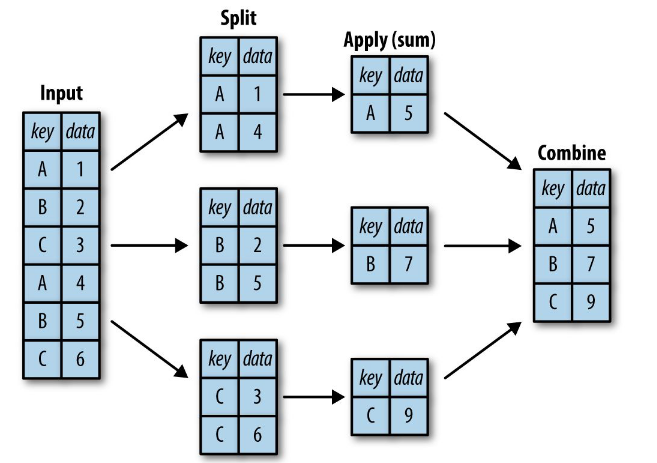

The power of the `GroupBy` is that it  abstracts away these steps: the user need not think about how the computation is  done under the hood, but rather thinks about the operation as a whole.

In [47]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'data': range(6)}, columns=['key', 'data'])
df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


We can compute the most basic **split-apply-combine **operation with the `groupby()`  method of `DataFrames`, passing the name of the desired key column:

In [48]:
df.groupby('key')

Notice that what is returned is not a set of `DataFrames`, but a `DataFrameGroupBy`  object. This object is where the magic is: you can think of it as a special view of the  `DataFrame`, which is poised to dig into the groups but does no actual computation  until the aggregation is applied. This “**lazy evaluation**” approach means that common  aggregates can be implemented very efficiently in a way that is almost transparent to  the user.

To produce a result, we can apply an **aggregate** to this `DataFrameGroupBy` object,  which will perform the appropriate **apply/combine steps** to produce the desired  result:

In [49]:
# Group and sum
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


The sum() method is just one possibility here; you can apply virtually any common  Pandas or NumPy aggregation function, as well as virtually any valid `DataFrame`  operation, as we will see in the following discussion.

### The GroupBy object

The `GroupBy` object is a very flexible abstraction. In many ways, you can simply treat  it as if it’s a **collection of DataFrames**, and it does the difficult things under the hood.  Let’s see some examples using the Planets data.


Perhaps the most important operations made available by a GroupBy are `aggregate`,  `filter`, `transform`, and `apply`.

We’ll discuss each of these, but before that let’s introduce some of the other functionality that can be used with the basic `GroupBy` operation.

**Column indexing.** The `GroupBy` object supports **column indexing** in the same way as  the *DataFrame*, and returns a *modified `GroupBy` object*. For example:

In [50]:
planets.head(15)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008
6,Radial Velocity,1,1773.400,4.64,18.15,2002
7,Radial Velocity,1,798.500,NaN,21.41,1996
8,Radial Velocity,1,993.300,10.30,73.10,2008
9,Radial Velocity,2,452.800,1.99,74.79,2010


In [51]:
planets.groupby('method')

In [52]:
planets.groupby('method')['orbital_period']  # Column indexing (index by column)

Here we’ve selected a particular `Series` group from the original `DataFrame` group by  reference to its column name. As with the `GroupBy` object, no computation is done  until we call some aggregate on the object:

In [53]:
planets.groupby('method')['orbital_period'].median()

,orbital_period
method,
Astrometry,631.180000
Eclipse Timing Variations,4343.500000
Imaging,27500.000000
Microlensing,3300.000000
Orbital Brightness Modulation,0.342887
Pulsar Timing,66.541900
Pulsation Timing Variations,1170.000000
Radial Velocity,360.200000
Transit,5.714932


**Iteration over groups.** The `GroupBy` object supports direct iteration over the groups,  returning each group as a `Series` or `DataFrame`:

In [54]:
for (method, group) in planets.groupby('method'):
    print("{0:30s} shape={1}".format(method, group.shape))

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


This can be useful for doing certain things manually, though it is often much faster to  use the built-in apply functionality, which we will discuss momentarily.

**Dispatch methods.** Through some Python class magic, any method not explicitly  implemented by the `GroupBy` object will be passed through and called on the groups,  whether they are `DataFrame` or `Series` objects. For example, you can use the  `describe()` method of `DataFrames` to perform a set of aggregations that describe each  group in the data:

In [55]:
planets.groupby('method')['year']

In [56]:
planets.groupby('method')['year'].describe()

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Astrometry,2.0,2011.500000,2.121320,2010.0,2010.75,2011.5,2012.25,2013.0
Eclipse Timing Variations,9.0,2010.000000,1.414214,2008.0,2009.00,2010.0,2011.00,2012.0
Imaging,38.0,2009.131579,2.781901,2004.0,2008.00,2009.0,2011.00,2013.0
Microlensing,23.0,2009.782609,2.859697,2004.0,2008.00,2010.0,2012.00,2013.0
Orbital Brightness Modulation,3.0,2011.666667,1.154701,2011.0,2011.00,2011.0,2012.00,2013.0
Pulsar Timing,5.0,1998.400000,8.384510,1992.0,1992.00,1994.0,2003.00,2011.0
Pulsation Timing Variations,1.0,2007.000000,NaN,2007.0,2007.00,2007.0,2007.00,2007.0
Radial Velocity,553.0,2007.518987,4.249052,1989.0,2005.00,2009.0,2011.00,2014.0
Transit,397.0,2011.236776,2.077867,2002.0,2010.00,2012.0,2013.00,2014.0


This is just one example of the utility of dispatch methods. Notice that they are  applied to each individual group, and the results are then combined within `GroupBy`  and returned. Again, any valid `DataFrame`/`Series` method can be used on the corresponding `GroupBy` object, which allows for some very flexible and powerful  operations!

### Aggregate, filter, transform, apply

The preceding discussion focused on aggregation for the combine operation, but  there are more options available. In particular, GroupBy objects have `aggregate(),`  `filter()`, `transform()`, and `apply()` methods that efficiently implement a variety of  useful operations before combining the grouped data.

In [57]:
rng = np.random.RandomState(0)
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'data1': range(6),
                   'data2': rng.randint(0, 10, 6)},
                   columns = ['key', 'data1', 'data2'])
df

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


**1- Aggregation.** We’re now familiar with `GroupBy` aggregations with `sum()`, `median()`,  and the like, but the `aggregate()` method allows for even more flexibility. It can take  a string, a function, or a list thereof, and compute all the aggregates at once. Here is a  quick example combining all these:

In [58]:
df.groupby('key').aggregate(['min', np.median, max])

/tmp/ipython-input-968873422.py:1: FutureWarning: The provided callable <function median at 0x7edda511e840> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.groupby('key').aggregate(['min', np.median, max])
/tmp/ipython-input-968873422.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby('key').aggregate(['min', np.median, max])


data1            data2           
      min median max   min median max
key                                  
A       0    1.5   3     3    4.0   5
B       1    2.5   4     0    3.5   7
C       2    3.5   5     3    6.0   9

Another useful pattern is to pass a dictionary mapping column names to operations  to be applied on that column:

In [59]:
df.groupby('key').aggregate({'data1': 'min',
                             'data2': 'max'})

,data1,data2
key,,
A,0,5
B,1,7
C,2,9


**2- Filtering.** A filtering operation allows you to drop data **based on the group properties**. For example, we might want to keep all groups in which the standard deviation is  larger than some critical value:

In [60]:
def filter_func(x):
    return x['data2'].std() > 4

print(df); print(df.groupby('key').std());
df.groupby('key').filter(filter_func)
# Here because group A does not have a standard deviation greater  than 4,
# it is dropped from the result.

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
       data1     data2
key                   
A    2.12132  1.414214
B    2.12132  4.949747
C    2.12132  4.242641


,key,data1,data2
1,B,1,0
2,C,2,3
4,B,4,7
5,C,5,9


Explanation:

Here is the breakdown of why the output of `df.groupby('key').filter(filter_func)` contains only the data for keys B and C:

1: The Filtering Logic

The function filter_func(x) calculates the standard deviation (std()) of the 'data2' column for each group and checks if it is greater than 4.

* Group A: data2 values are [5, 3]. The standard deviation is approximately 1.414. Since 1.414 not > 4, this group is **dropped**.
* Group B: data2 values are [0, 7]. The standard deviation is approximately 4.950. Since 4.950 > 4, this group is **kept**.
* Group C: data2 values are [3, 9]. The standard deviation is approximately 4.243. Since 4.243 > 4, this group is **kept**.



2: The Resulting DataFrame

The output is a sub-selection of the original DataFrame. Unlike a standard aggregation (like mean() or sum()), .filter() does not change the shape of the individual rows; it either keeps the entire group or discards it.

* Preserved Rows: Rows 1, 2, 4, and 5 remain because they belong to groups B and C.
* Removed Rows: Rows 0 and 3 are gone because they belonged to group A.
* Index: The original row indices (1, 2, 4, 5) are preserved in the final output.

**3- Transformation.** While *aggregation* must return a reduced version of the data, *transformation* can return some ***transformed version of the full data to recombine***.

For  such a transformation, the output is the **same shape as the input**.

A common example  is to center the data by subtracting the group-wise mean:

In [61]:
df

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


In [62]:
# Group and compute mean
df.groupby('key').mean()

,data1,data2
key,,
A,1.5,4.0
B,2.5,3.5
C,3.5,6.0


In [63]:
# The transformation
df.groupby('key').transform(lambda x: x - x.mean())

,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


Explanation:

In this operation, you are performing **group-wise centering** (de-meaning), which scales data relative to its group average.

1: The Transformation Logic"

The operation `x - x.mean()` is applied to each group ('A', 'B', and 'C') independently. For every individual value in a group, Pandas subtracts the average value of that specific group.

* Group A: data1 values are [0, 3]. The mean is 1.5.
    * Row 0: 0 - 1.5 = -1.5
    * Row 3: 3 - 1.5 = 1.5
* Group B: data2 values are [0, 7]. The mean is 3.5.
    * Row 1: 0 - 3.5 = -3.5
    * Row 4: 7 - 3.5 = 3.5



2: Characteristics of .transform()"

* Broadcasted Shape: The output has 6 rows, exactly like the input df.
* Alignment: Pandas automatically aligns the results back to the original indices, even if the groups were not contiguous.
* Column Preservation: The transformation is applied column-wise to all numeric data (data1 and data2), but the grouping column (key) is dropped from the result because it was used as the index for calculation.

**4- Applying.** The `apply()` method lets you apply an arbitrary function to the  group results. The function should take a `DataFrame`, and return either a Pandas  object (e.g., `DataFrame`, `Series`) or a scalar; the combine operation will be tailored to  the type of output returned.  

For example, here is an `apply()` that normalizes the first column by the sum of the  second:

In [64]:
df['data2'].sum()

np.int64(27)

In [65]:
def norm_by_data2(x):
    # x is a DataFrame of group values
    x['data1'] /= x['data2'].sum()
    return x

print(df)
df.groupby('key').apply(norm_by_data2)

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9


/tmp/ipython-input-2197200329.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('key').apply(norm_by_data2)


key     data1  data2
key                       
A   0   A  0.000000      5
    3   A  0.375000      3
B   1   B  0.142857      0
    4   B  0.571429      7
C   2   C  0.166667      3
    5   C  0.416667      9

Explantion:

1. The Normalization Logic
The function `norm_by_data2(x)` takes each group, divides the values in the `data1` column by the sum of the `data2` column for that specific group, and returns the modified group.

* Group A: `data2` values are [5, 3], so the sum is 8.
    * Row 0:  0 / 8 = 0.000000
    * Row 3:  3 / 8 = 0.375000
* Group B: `data2` values are [0, 7], so the sum is 7.
    * Row 1:  1 / 7 = 0.142857
    * Row 4:  4 / 7 = 0.571429
* Group C: `data2` values are [3, 9], so the sum is 12.
    * Row 2:  2 / 12 = 0.166667
    * Row 5:  5 / 12 = 0.416667

2. The MultiIndex Output
The resulting `DataFrame` has a **hierarchical index** (MultiIndex).

* Level 0 (key): The first level of the index is the grouping key ('A', 'B', 'C').
* Level 1: The second level preserves the original row indices (0, 1, 2, 3, 4, 5).

`apply()` within a `GroupBy` is quite flexible: the only criterion is that the function takes  a `DataFrame` and returns a Pandas object or scalar; what you do in the middle is up to  you!

### Specifying the split key

In the simple examples presented before, we split the `DataFrame` on a single column  name. This is just one of many options by which the groups can be defined, and we’ll  go through some other options for group specification here.

**A list, array, series, or index providing the grouping keys.** The key can be any series or list  with a length matching that of the `DataFrame`. For example:

In [66]:
L = [0, 1, 0, 1, 2, 0]
print(df);
df.groupby(L).sum()

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9


,key,data1,data2
0,ACC,7,17
1,BA,4,3
2,B,4,7


Explanation:

1. Mapping the External Key

The list L = [0, 1, 0, 1, 2, 0] acts as a "virtual column" that assigns a new group ID to each row based on its position. Pandas aligns L with the index of df:
* Rows assigned to Group 0: Indices 0, 2, and 5 (corresponding to L[0], L[2], L[5]).
* Rows assigned to Group 1: Indices 1 and 3 (corresponding to L[1], L[3]).
* Rows assigned to Group 2: Index 4 (corresponding to L[4]).

2. Group-wise Summation
Once the rows are grouped by the values in L, the `.sum()` function is applied to the data within those groups:

* Group 0 (Indices 0, 2, 5):
    * key: 'A' + 'C' + 'C' = ACC
    * data1: 0 + 2 + 5 = 7
    * data2: 5 + 3 + 9 = 17
* Group 1 (Indices 1, 3):
    * key: 'B' + 'A' = BA
    * data1: 1 + 3 = 4
    * data2: 0 + 3 = 3
* Group 2 (Index 4):
    * key: 'B' = B
    * data1: 4 = 4
    * data2: 7 = 7

3. Key Characteristics
* Index Transformation: The unique values from the list L (0, 1, 2) become the new index of the resulting `DataFrame`.
* String Aggregation: Because the `key` column contains strings, the `.sum()` operation performs **string concatenation** (e.g., 'A' + 'C' + 'C' = 'ACC').
* Alignment: This method requires the length of the external list (L) to be exactly equal to the number of rows in the `DataFrame`.

Of course, this means there’s another, more verbose way of accomplishing the  df.groupby('key') from before:

In [67]:
print(df);
df.groupby(df['key']).sum()

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9


,data1,data2
key,,
A,3,8
B,5,7
C,7,12


**A dictionary or series mapping index to group.** Another method is to provide a dictionary  that maps index values to the group keys:

In [68]:
df2 = df.set_index('key')
mapping = {'A': 'vowel', 'B': 'consonant', 'C': 'consonant'}
print(df)
print(df2);
df2.groupby(mapping).sum()

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
     data1  data2
key              
A        0      5
B        1      0
C        2      3
A        3      3
B        4      7
C        5      9


,data1,data2
key,,
consonant,12,19
vowel,3,8


**Any Python function.** Similar to mapping, you can pass any Python function that will  input the index value and output the group:

In [69]:
print(df2);
df2.groupby(str.lower).mean()

     data1  data2
key              
A        0      5
B        1      0
C        2      3
A        3      3
B        4      7
C        5      9


,data1,data2
key,,
a,1.5,4.0
b,2.5,3.5
c,3.5,6.0
